# Depression Detection — Holdout Experiment
## Train on DAIC-WOZ  →  Test on Clasificación Final

**Design:**
- **Train set**: DAIC-WOZ embeddings (`embeddings_daic/`)
- **Test set**:  Clasificación Final embeddings (`embeddings_v2/depresion/`)
- Manifest-free loader (`root.rglob(model_key)`) — scans the folder tree directly, finds every patient.
- SMOTE / BorderlineSMOTE applied **only on the DAIC-WOZ training set**.
- StandardScaler fitted **only on DAIC-WOZ**, then applied to Clasificación Final.
- LazyClassifier used to screen all sklearn classifiers per (embedding model × pipeline).
- Extended metrics: Accuracy, F1 Macro, F1 (depression class), ROC AUC, Balanced Accuracy.
- Confusion matrix + ROC curve saved per best configuration.
- Per-patient majority-vote aggregation for the clinically meaningful metric.

In [1]:
# ==============================================================================
# CELL 0 — Imports & paths
# ==============================================================================
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, classification_report,
)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from lazypredict.Supervised import LazyClassifier

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/embeddings_daic"
TEST_DIR  = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/depresion"

MODELS_TO_TEST = [
    "xlsr-300m",
    "xlsr-53",
    "whisper-large-encoder",
    "wav2vec2-large-robust",
    "wavlm-large",
    "hubert-large",
]

SEED = 42

OUTPUT_DIR = Path("holdout_outputs")
PLOTS_DIR  = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

print("Imports OK")
print(f"  TRAIN: {TRAIN_DIR}")
print(f"  TEST:  {TEST_DIR}")


Imports OK
  TRAIN: /home/ci2dt2-ai/Proyectos/Psiquiatria/embeddings_daic
  TEST:  /home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/depresion


In [2]:
# ==============================================================================
# CELL 1 — Manifest-free folder scanner
#
# Same approach used in the merged CV notebook: root.rglob(model_key) finds
# every folder named exactly model_key anywhere under root, regardless of
# whether a 'condition' subfolder exists. This is what correctly finds all
# patients (manifest.json is never read).
#
# Supported layouts:
#   NEW (DAIC):  root/{condition}/{class_X}/{model}/{audio_id}/segment_N/embedding.json
#   OLD (Clas.): root/{class_X}/{model}/{audio_id}/segment_N/embedding.json
# ==============================================================================

def scan_embeddings(root: Path, model_key: str, label: str = ""):
    """
    Walk root and collect all embedding.json files for model_key.
    Returns (X, y, groups) as numpy arrays.
    groups = audio_id (patient identifier), used for per-patient aggregation.
    """
    all_X, all_y, all_groups = [], [], []

    model_dirs = [d for d in root.rglob(model_key) if d.is_dir()]
    if not model_dirs:
        print(f"  [WARN] No folder named {model_key!r} found under {root}")
        return np.array([]), np.array([]), np.array([])

    n_loaded = n_missing = 0

    for model_dir in sorted(model_dirs):
        class_dir   = model_dir.parent
        class_label = class_dir.name
        if not class_label.startswith("class_"):
            continue
        class_id = int(class_label.split("_")[-1])

        for audio_dir in sorted(model_dir.iterdir()):
            if not audio_dir.is_dir():
                continue
            audio_id = audio_dir.name

            for seg_dir in sorted(audio_dir.iterdir()):
                if not seg_dir.is_dir() or not seg_dir.name.startswith("segment_"):
                    continue
                emb_file = seg_dir / "embedding.json"
                if not emb_file.exists():
                    n_missing += 1
                    continue
                try:
                    with open(emb_file) as f:
                        data = json.load(f)
                    emb = data.get("embedding")
                    if emb is None:
                        n_missing += 1
                        continue
                    all_X.append(np.array(emb, dtype=np.float32))
                    all_y.append(class_id)
                    all_groups.append(audio_id)
                    n_loaded += 1
                except Exception:
                    n_missing += 1

    tag = f"[{label}] " if label else ""
    status = f"{n_loaded} segments loaded"
    if n_missing:
        status += f", {n_missing} missing/corrupt"
    print(f"  {tag}{root.name}/{model_key}: {status} | "
          f"class_0={all_y.count(0)}, class_1={all_y.count(1)}, "
          f"patients={len(set(all_groups))}")

    if not all_X:
        return np.array([]), np.array([]), np.array([])

    return (
        np.stack(all_X).astype(np.float32),
        np.array(all_y, dtype=np.int32),
        np.array(all_groups),
    )


def load_train_test(model_key: str):
    """Load DAIC-WOZ as train and Clasificación Final as test."""
    print(f"\nLoading {model_key} ...")
    X_tr, y_tr, g_tr = scan_embeddings(Path(TRAIN_DIR), model_key, label="TRAIN")
    X_te, y_te, g_te = scan_embeddings(Path(TEST_DIR),  model_key, label="TEST")
    return X_tr, y_tr, g_tr, X_te, y_te, g_te


# Quick sanity check
X_tr, y_tr, g_tr, X_te, y_te, g_te = load_train_test("xlsr-300m")
print(f"\nTRAIN shape: {X_tr.shape}  |  TEST shape: {X_te.shape}")
print(f"Embedding dim match: {X_tr.shape[1] == X_te.shape[1]}")



Loading xlsr-300m ...
  [TRAIN] embeddings_daic/xlsr-300m: 36452 segments loaded | class_0=25375, class_1=11077, patients=189
  [TEST] depresion/xlsr-300m: 5252 segments loaded | class_0=3799, class_1=1453, patients=79

TRAIN shape: (36452, 1024)  |  TEST shape: (5252, 1024)
Embedding dim match: True


In [3]:
# ==============================================================================
# CELL 2 — Helpers: SMOTE-safe resampling, extended metrics, plots
# ==============================================================================

def smote_safe(X, y, kind="smote", seed=SEED):
    """Apply SMOTE/BorderlineSMOTE only if the minority class has enough samples."""
    min_count = int(np.bincount(y).min())
    k = max(1, min(5,  min_count - 1))
    m = max(1, min(10, min_count - 1))
    try:
        if kind == "borderline":
            return BorderlineSMOTE(random_state=seed, k_neighbors=k, m_neighbors=m).fit_resample(X, y)
        return SMOTE(random_state=seed, k_neighbors=k).fit_resample(X, y)
    except Exception:
        return X, y


def extended_metrics(y_true, y_pred, y_prob=None) -> dict:
    """Compute the full metric set used across the project."""
    out = {
        "Accuracy":          accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1 Macro":          f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "F1 Weighted":       f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Dep":            f1_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0),
    }
    if y_prob is not None:
        try:
            out["ROC AUC"] = roc_auc_score(y_true, y_prob)
        except Exception:
            out["ROC AUC"] = float("nan")
    return out


def plot_confusion_matrix(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Dep.", "Dep."],
                yticklabels=["No Dep.", "Dep."])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def plot_roc_curve(y_true, y_prob, title, path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

print("Helpers defined.")


Helpers defined.


In [4]:
# ==============================================================================
# CELL 3 — Main holdout experiment (LazyClassifier × 7 pipelines × 6 models)
#
# For each SSL model × each pipeline:
#   1. Load DAIC-WOZ (train) and Clasificación Final (test)
#   2. Apply preprocessing (scaler, PCA, SMOTE) — fitted on train only
#   3. Run LazyClassifier: trains every sklearn classifier on DAIC-WOZ,
#      evaluates on Clasificación Final
#   4. Recompute extended metrics (F1 Dep, Balanced Acc, ROC AUC) for the
#      best-scoring classifier and save confusion matrix + ROC curve
#
# Pipelines tested
# ----------------
#   P0  Raw embeddings, no SMOTE, class_weight=balanced
#   P1  Raw embeddings + SMOTE
#   P2  StandardScaler + SMOTE
#   P3  Raw embeddings + BorderlineSMOTE
#   P4  StandardScaler + BorderlineSMOTE
#   P5  StandardScaler + PCA(15) + SMOTE
#   P6  StandardScaler + PCA(15) + BorderlineSMOTE
# ==============================================================================

PIPELINES = {
    "P0_raw_balanced":            {"scaler": False, "pca": False, "smote": None},
    "P1_raw_smote":               {"scaler": False, "pca": False, "smote": "smote"},
    "P2_scaler_smote":            {"scaler": True,  "pca": False, "smote": "smote"},
    "P3_raw_borderline":          {"scaler": False, "pca": False, "smote": "borderline"},
    "P4_scaler_borderline":       {"scaler": True,  "pca": False, "smote": "borderline"},
    "P5_scaler_pca15_smote":      {"scaler": True,  "pca": True,  "smote": "smote"},
    "P6_scaler_pca15_borderline": {"scaler": True,  "pca": True,  "smote": "borderline"},
}

all_lazy_results = []   # one row per (model, pipeline, classifier)

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"  {emb_model}")
    print(f"{'='*80}")

    try:
        X_tr, y_tr, g_tr, X_te, y_te, g_te = load_train_test(emb_model)
    except Exception as e:
        print(f"  [ERROR] loading: {e}")
        continue

    if X_tr.size == 0 or X_te.size == 0:
        print("  [SKIP] empty train or test set")
        continue

    for pipe_name, pipe_cfg in PIPELINES.items():
        X_train, y_train = X_tr.copy(), y_tr.copy()
        X_test            = X_te.copy()

        # 1. StandardScaler — fit on train, transform both
        if pipe_cfg["scaler"]:
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        # 2. PCA — fit on train, transform both
        if pipe_cfg["pca"]:
            pca     = PCA(n_components=15, random_state=SEED)
            X_train = pca.fit_transform(X_train)
            X_test  = pca.transform(X_test)

        # 3. SMOTE / BorderlineSMOTE — train only
        if pipe_cfg["smote"]:
            X_train, y_train = smote_safe(X_train, y_train, kind=pipe_cfg["smote"])

        # 4. LazyClassifier — train on DAIC-WOZ, evaluate on Clasificación Final
        clf = LazyClassifier(verbose=0, ignore_warnings=True,
                             custom_metric=f1_macro, predictions=False)
        if pipe_cfg["smote"] is None:
            for _, m in clf.models.items():
                if hasattr(m, "class_weight"):
                    m.class_weight = "balanced"

        try:
            lazy_res, predictions = clf.fit(
                pd.DataFrame(X_train), pd.DataFrame(X_test),
                pd.Series(y_train),    pd.Series(y_te),
            )
            lazy_res = lazy_res.reset_index()
            lazy_res.columns = ["Classifier"] + list(lazy_res.columns[1:])
            lazy_res["Embedding_Model"] = emb_model
            lazy_res["Pipeline"]        = pipe_name
            all_lazy_results.append(lazy_res)

            top = lazy_res.sort_values("ROC AUC", ascending=False).head(3)
            print(f"\n  [{pipe_name}] top-3 (LazyClassifier ROC AUC):")
            for _, r in top.iterrows():
                print(f"    {r['Classifier']:<40s} roc_auc={r.get('ROC AUC', float('nan')):.3f}  "
                      f"f1_macro={r.get('f1_macro', float('nan')):.3f}  "
                      f"acc={r.get('Accuracy', float('nan')):.3f}")

        except Exception as e:
            print(f"  [{pipe_name}] LazyClassifier error: {e}")

# ── Aggregate & save ─────────────────────────────────────────────────────────
if all_lazy_results:
    df_all = pd.concat(all_lazy_results, ignore_index=True)
    df_all.to_csv(OUTPUT_DIR / "holdout_all_results.csv", index=False)
    print(f"\nAll LazyClassifier results saved → {OUTPUT_DIR / 'holdout_all_results.csv'}  "
          f"({len(df_all)} rows)")

    print(f"\n{'='*80}")
    print("GLOBAL TOP-20 (by ROC AUC)")
    print(f"{'='*80}")
    top20 = df_all.sort_values("ROC AUC", ascending=False).head(20)
    cols = [c for c in ["Embedding_Model","Pipeline","Classifier","Accuracy",
                         "Balanced Accuracy","F1 Score","f1_macro","ROC AUC"]
            if c in top20.columns]
    print(top20[cols].to_string(index=False))



  xlsr-300m

Loading xlsr-300m ...
  [TRAIN] embeddings_daic/xlsr-300m: 36452 segments loaded | class_0=25375, class_1=11077, patients=189
  [TEST] depresion/xlsr-300m: 5252 segments loaded | class_0=3799, class_1=1453, patients=79


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



  [P0_raw_balanced] top-3 (LazyClassifier ROC AUC):
    BernoulliNB                              roc_auc=0.545  f1_macro=0.420  acc=0.723
    NearestCentroid                          roc_auc=0.528  f1_macro=0.420  acc=0.723
    ExtraTreesClassifier                     roc_auc=0.526  f1_macro=0.385  acc=0.387


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



  [P1_raw_smote] top-3 (LazyClassifier ROC AUC):
    BernoulliNB                              roc_auc=0.545  f1_macro=0.420  acc=0.723
    NearestCentroid                          roc_auc=0.529  f1_macro=0.420  acc=0.723
    ExtraTreeClassifier                      roc_auc=0.517  f1_macro=0.492  acc=0.521


...


  [P2_scaler_smote] top-3 (LazyClassifier ROC AUC):
    NearestCentroid                          roc_auc=0.515  f1_macro=0.420  acc=0.723
    BernoulliNB                              roc_auc=0.514  f1_macro=0.420  acc=0.723
    SVC                                      roc_auc=0.512  f1_macro=0.420  acc=0.723


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



  [P3_raw_borderline] top-3 (LazyClassifier ROC AUC):
    NearestCentroid                          roc_auc=0.515  f1_macro=0.420  acc=0.723
    BernoulliNB                              roc_auc=0.514  f1_macro=0.420  acc=0.723
    SVC                                      roc_auc=0.512  f1_macro=0.420  acc=0.723


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



  [P4_scaler_borderline] top-3 (LazyClassifier ROC AUC):
    NearestCentroid                          roc_auc=0.515  f1_macro=0.420  acc=0.723
    BernoulliNB                              roc_auc=0.513  f1_macro=0.420  acc=0.723
    SVC                                      roc_auc=0.513  f1_macro=0.420  acc=0.723

  [P5_scaler_pca15_smote] top-3 (LazyClassifier ROC AUC):
    NuSVC                                    roc_auc=0.520  f1_macro=0.466  acc=0.690
    SGDClassifier                            roc_auc=0.509  f1_macro=0.444  acc=0.706
    KNeighborsClassifier                     roc_auc=0.508  f1_macro=0.506  acc=0.581

  [P6_scaler_pca15_borderline] top-3 (LazyClassifier ROC AUC):
    NuSVC                                    roc_auc=0.520  f1_macro=0.494  acc=0.663
    KNeighborsClassifier                     roc_auc=0.516  f1_macro=0.480  acc=0.501
    PassiveAggressiveClassifier              roc_auc=0.514  f1_macro=0.427  acc=0.720

All LazyClassifier results saved → holdout_o

Best configuration per SSL model:
      Embedding_Model                   Pipeline                  Classifier  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust P6_scaler_pca15_borderline PassiveAggressiveClassifier  0.658797           0.558446  0.653075  0.559865 0.596733
whisper-large-encoder P6_scaler_pca15_borderline PassiveAggressiveClassifier  0.439642           0.548273  0.440069  0.439640 0.581124
            xlsr-300m            P2_scaler_smote                 BernoulliNB  0.723343           0.500000  0.607222  0.419733 0.547724
              xlsr-53 P6_scaler_pca15_borderline PassiveAggressiveClassifier  0.512757           0.529962  0.537735  0.492832 0.544716
          wavlm-large            P2_scaler_smote        KNeighborsClassifier  0.514471           0.527109  0.539643  0.492700 0.529100
         hubert-large P6_scaler_pca15_borderline                       NuSVC  0.663176           0.505586  0.624514  0.493634 0.520252

Saved → holdout_outp

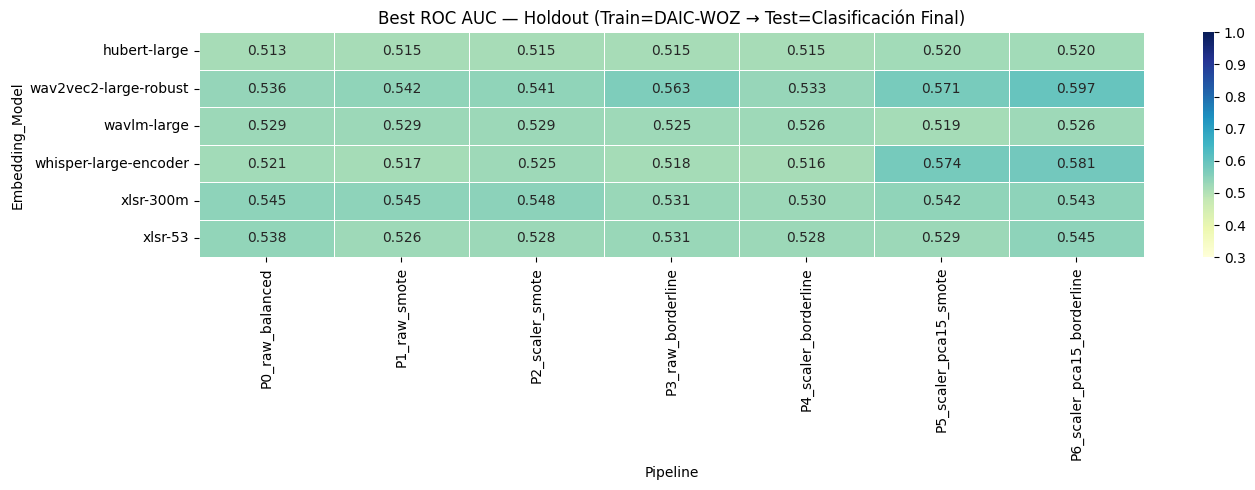

Saved → holdout_outputs/plots/holdout_heatmap_auc.png


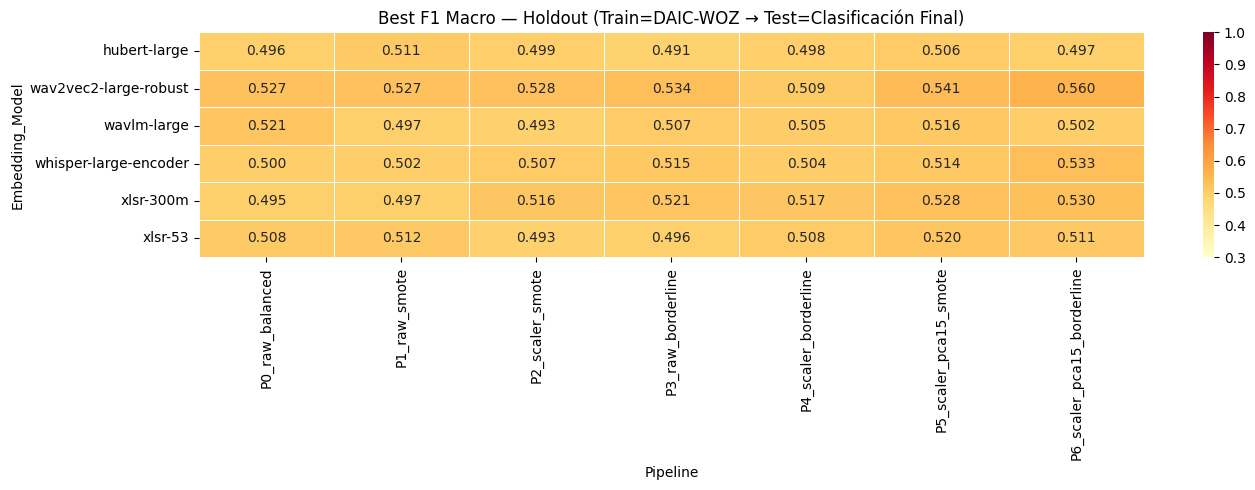

Saved → holdout_outputs/plots/holdout_heatmap.png


In [5]:
# ==============================================================================
# CELL 4 — Summary: best pipeline × classifier per embedding model + heatmap
# ==============================================================================

if 'df_all' in dir() and len(df_all):
    best_per_model = (
        df_all
        .sort_values("ROC AUC", ascending=False)
        .groupby("Embedding_Model", as_index=False)
        .first()
    )
    cols = [c for c in ["Embedding_Model","Pipeline","Classifier","Accuracy",
                         "Balanced Accuracy","F1 Score","f1_macro","ROC AUC"]
            if c in best_per_model.columns]
    best_per_model = best_per_model[cols].sort_values("ROC AUC", ascending=False)

    print("Best configuration per SSL model:")
    print(best_per_model.to_string(index=False))
    best_per_model.to_csv(OUTPUT_DIR / "holdout_best_per_model.csv", index=False)
    print(f"\nSaved → {OUTPUT_DIR / 'holdout_best_per_model.csv'}")

    # Heatmap — best ROC AUC per (embedding_model × pipeline)  [PRIMARY metric]
    if "ROC AUC" in df_all.columns:
        pivot_auc = (
            df_all
            .groupby(["Embedding_Model", "Pipeline"])["ROC AUC"]
            .max()
            .unstack("Pipeline")
            .fillna(0)
        )
        plt.figure(figsize=(14, 5))
        sns.heatmap(pivot_auc, annot=True, fmt=".3f", cmap="YlGnBu",
                    linewidths=0.5, vmin=0.3, vmax=1.0)
        plt.title("Best ROC AUC — Holdout (Train=DAIC-WOZ → Test=Clasificación Final)")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "holdout_heatmap_auc.png", dpi=150)
        plt.show()
        print(f"Saved → {PLOTS_DIR / 'holdout_heatmap_auc.png'}")

    # Secondary heatmap — F1 Macro, for reference
    pivot = (
        df_all
        .groupby(["Embedding_Model", "Pipeline"])["f1_macro"]
        .max()
        .unstack("Pipeline")
        .fillna(0)
    )
    plt.figure(figsize=(14, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, vmin=0.3, vmax=1.0)
    plt.title("Best F1 Macro — Holdout (Train=DAIC-WOZ → Test=Clasificación Final)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "holdout_heatmap.png", dpi=150)
    plt.show()
    print(f"Saved → {PLOTS_DIR / 'holdout_heatmap.png'}")


In [7]:
# ==============================================================================
# CELL 5 — Detailed evaluation of the winning configuration
#
# Rebuilds the best (model, pipeline, classifier) combination found in Cell 4,
# refits on full DAIC-WOZ, evaluates on Clasificación Final with the
# extended metric set, confusion matrix, ROC curve, and per-patient
# majority-vote aggregation.
#
# Update EMB_MODEL / PIPE_NAME / CLASSIFIER_NAME below from Cell 4's table,
# or leave as-is to auto-pick the global best.
# ==============================================================================
from sklearn.utils import all_estimators
from sklearn.base import ClassifierMixin

# ← Auto-pick the best row from Cell 4, or override manually
if 'best_per_model' in dir() and len(best_per_model):
    best_row = best_per_model.iloc[0]
    EMB_MODEL       = best_row["Embedding_Model"]
    PIPE_NAME       = best_row["Pipeline"]
    CLASSIFIER_NAME = best_row["Classifier"]
else:
    EMB_MODEL       = "wav2vec2-large-robust"
    PIPE_NAME       = "P4_scaler_borderline"
    CLASSIFIER_NAME = "ExtraTreesClassifier"

print(f"Winning configuration: {EMB_MODEL} | {PIPE_NAME} | {CLASSIFIER_NAME}")

pipe_cfg = PIPELINES[PIPE_NAME]
X_tr, y_tr, g_tr, X_te, y_te, g_te = load_train_test(EMB_MODEL)

X_train, y_train = X_tr.copy(), y_tr.copy()
X_test            = X_te.copy()

if pipe_cfg["scaler"]:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

if pipe_cfg["pca"]:
    pca     = PCA(n_components=15, random_state=SEED)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)

if pipe_cfg["smote"]:
    X_train, y_train = smote_safe(X_train, y_train, kind=pipe_cfg["smote"])

# Find the matching sklearn estimator class by name
estimator_cls = None
for name, cls in all_estimators(type_filter="classifier"):
    if name == CLASSIFIER_NAME:
        estimator_cls = cls
        break

if estimator_cls is None:
    raise ValueError(f"Could not find classifier class for '{CLASSIFIER_NAME}'")

try:
    model = estimator_cls(random_state=SEED)
except TypeError:
    model = estimator_cls()
if hasattr(model, "class_weight") and pipe_cfg["smote"] is None:
    model.set_params(class_weight="balanced")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

metrics = extended_metrics(y_te, y_pred, y_prob)
print(f"\n{'='*60}")
print(f"  HOLDOUT TEST RESULTS — {EMB_MODEL} | {PIPE_NAME} | {CLASSIFIER_NAME}")
print(f"{'='*60}")
for k, v in metrics.items():
    print(f"  {k:<20s}: {v:.4f}")
print(f"\n{classification_report(y_te, y_pred, zero_division=0)}")

plot_confusion_matrix(
    y_te, y_pred,
    title=f"{EMB_MODEL} | {PIPE_NAME} | {CLASSIFIER_NAME}",
    path=PLOTS_DIR / "holdout_best_confusion.png",
)
if y_prob is not None:
    plot_roc_curve(
        y_te, y_prob,
        title=f"ROC: {EMB_MODEL} | {PIPE_NAME} | {CLASSIFIER_NAME}",
        path=PLOTS_DIR / "holdout_best_roc.png",
    )

print(f"\nSaved confusion matrix → {PLOTS_DIR / 'holdout_best_confusion.png'}")
if y_prob is not None:
    print(f"Saved ROC curve        → {PLOTS_DIR / 'holdout_best_roc.png'}")


Winning configuration: wav2vec2-large-robust | P6_scaler_pca15_borderline | PassiveAggressiveClassifier

Loading wav2vec2-large-robust ...


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# CELL 6 — Per-patient majority vote (clinically meaningful metric)
#
# Aggregates segment-level predictions to one prediction per patient using
# majority vote, then recomputes the full metric set at the patient level.
# ==============================================================================

df_preds = pd.DataFrame({
    "audio_id":   g_te,
    "y_true":     y_te,
    "y_pred":     y_pred,
})
if y_prob is not None:
    df_preds["y_prob_dep"] = y_prob

agg = {"y_true": ("y_true", "first"),
       "y_pred_mv": ("y_pred", lambda x: int(x.mode()[0]))}
if "y_prob_dep" in df_preds.columns:
    agg["y_prob_mean"] = ("y_prob_dep", "mean")

patient_df = df_preds.groupby("audio_id").agg(**agg).reset_index()

patient_metrics = extended_metrics(
    patient_df["y_true"], patient_df["y_pred_mv"],
    patient_df["y_prob_mean"] if "y_prob_mean" in patient_df.columns else None,
)

print(f"Per-patient majority vote — {EMB_MODEL} | {PIPE_NAME} | {CLASSIFIER_NAME}")
print(f"Patients: {len(patient_df)}")
print(f"{'='*50}")
for k, v in patient_metrics.items():
    print(f"  {k:<20s}: {v:.4f}")

patient_df.to_csv(OUTPUT_DIR / "holdout_patient_predictions.csv", index=False)
print(f"\nSaved → {OUTPUT_DIR / 'holdout_patient_predictions.csv'}")

if "y_prob_mean" in patient_df.columns:
    plot_confusion_matrix(
        patient_df["y_true"], patient_df["y_pred_mv"],
        title=f"Per-Patient Majority Vote — {EMB_MODEL} | {PIPE_NAME}",
        path=PLOTS_DIR / "holdout_patient_confusion.png",
    )
    plot_roc_curve(
        patient_df["y_true"], patient_df["y_prob_mean"],
        title=f"Per-Patient ROC — {EMB_MODEL} | {PIPE_NAME}",
        path=PLOTS_DIR / "holdout_patient_roc.png",
    )
    print(f"Saved → {PLOTS_DIR / 'holdout_patient_confusion.png'}")
    print(f"Saved → {PLOTS_DIR / 'holdout_patient_roc.png'}")
